In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse.linalg import LinearOperator, lsqr
import scipy
import time
from scipy.interpolate import lagrange, RegularGridInterpolator
from ader_dg_transport.utils import gll, lagrange1st

from ader_dg_transport.dg_2D import wave_dg_2D, wave_dg_adjoint_2D, wave_dg_optimizer_receiver_2D

import importlib

import scipy.io as sio

In [3]:
data = sio.loadmat('Marmousi_vel.mat')['Marvel']

marmousi = np.copy(data[:, 600:1200])
marmousi[marmousi < 1500] = 1500
xs_ = np.linspace(0, 9_200, data.shape[1])[:marmousi.shape[1]]
xs_ -= xs_.min()
ys_ = np.linspace(0, 3_000, data.shape[0])

interp = RegularGridInterpolator((ys_, xs_), marmousi, method='nearest')

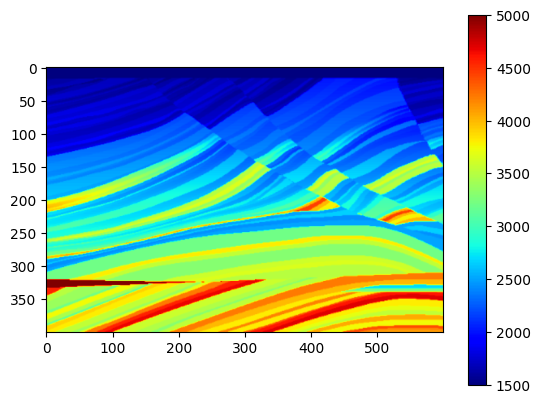

In [4]:
plt.imshow(marmousi, cmap='jet')
plt.colorbar()

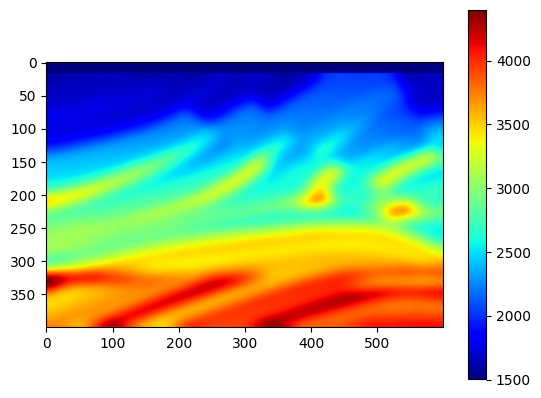

In [5]:
idx = np.where(marmousi[:, 0] > marmousi.min())[0][0]
semi_smooth_marmousi = np.copy(marmousi)
semi_smooth_marmousi[idx:] = scipy.ndimage.gaussian_filter(marmousi[idx:], sigma=10)

semi_smooth_interp = RegularGridInterpolator((ys_, xs_), semi_smooth_marmousi, method='nearest')
plt.imshow(semi_smooth_marmousi, cmap='jet')
plt.colorbar()

In [6]:
# idx = np.where(marmousi[:, 0] > marmousi.min())[0][0]
# smooth_marmousi = np.copy(marmousi)
# smooth_marmousi[idx:] = scipy.ndimage.gaussian_filter(marmousi[idx:], sigma=30)

# smooth_interp = RegularGridInterpolator((ys_, xs_), smooth_marmousi, method='nearest')
# plt.imshow(smooth_marmousi, cmap='jet')
# plt.colorbar()

In [7]:
xlim = xs_.max()
ylim = ys_.max()

ny = 10
# nx = 1 * ny
nx = 10
c = marmousi.max()

poly_order = 3

dx = xlim / nx
dy = ylim / ny
cfl = 1. / (2 * poly_order + 1)
dt = cfl * min(dx, dy) / c

tend = 6.0

nsteps = int(tend / dt) + 1
dt = tend / nsteps

In [8]:
dy / 3, dx / 3

(np.float64(100.0), np.float64(108.11850107906612))

In [8]:
sig = 0.5 * xlim / nx
f0 = 1.25
def F(t_in, f0):
    t = t_in - 0.3
    return (2 * np.pi * f0)**2 * ((4 * np.pi * (f0 * t - 1)**2) - 1) * np.exp(-2 * np.pi * (f0 * t - 1)**2)


def f(x, y, t, f0, xc):

    
    out = np.zeros(t.shape + (3,) + x.shape)

    out[:, 1] = F(t, f0)[:, None, None, None, None] * np.exp(-((x - xc)**2 + (y - 0.9 * ylim)**2) / (2 * sig**2))[None]
    return out



# ts = np.linspace(0, 3 / f0, 100)
# forcing = f(xs, 3, ts)

# ts = np.linspace(0, 3 / f0, 100)
# plt.plot(ts * f0, F(ts))

# ts = np.linspace(0, 5, int(1 / dt))
# plt.plot(ts, F(ts, f0=f0), '*')

# plt.figure()
# plt.tricontourf(xs.ravel(), ys.ravel(), f(xs - 1000, ys, np.array([1 / f0]), f0=2.5)[0, 1].ravel())

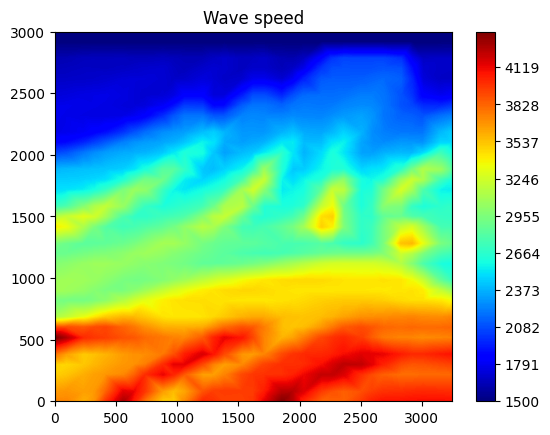

In [50]:
importlib.reload(wave_dg_2D)
importlib.reload(wave_dg_adjoint_2D)

forward_solver = wave_dg_2D.WaveDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
forward_solver.y_periodic = False
forward_solver.x_periodic = False

adjoint_solver = wave_dg_adjoint_2D.WaveAdjointDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
adjoint_solver.y_periodic = forward_solver.y_periodic
adjoint_solver.x_periodic = forward_solver.x_periodic

xs = forward_solver.xs
ys = forward_solver.ys

pts = np.vstack([ylim - ys.ravel(), xs.ravel()]).transpose()
# c_exact = interp(pts).reshape(forward_solver.c.shape)

c_exact = semi_smooth_interp(pts).reshape(forward_solver.c.shape)

r2 = (xs - (xlim / 2))**2 + (ys - 0.8 * ylim)**2
h0 = np.exp(-r2 / 500**2)

# # forward_solver.c[forward_solver.xs > 5] = 0.5
forward_solver.c[:] = c_exact
adjoint_solver.c[:] = forward_solver.c

plt.title(f'Wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_exact.ravel(), levels=1000, cmap='jet', vmax=c_exact.max())
plt.colorbar()

## Get target state

## Optimize

In [13]:
from functools import partial

dxs = [-1000, -500, 0.0, 500, 1000]
freqs = [1.0, 1.75, 2.5, 5.0, 7.5, 10.0]

forcing_funcs_dict = dict()
for f0 in freqs:
    forcing_funcs_dict[f0] = []
    for dx in dxs:
        xc = 0.5*xlim+dx
        forcing_funcs_dict[f0].append(partial(f, f0=f0, xc=xc))

In [14]:
target_data_dict = dict()
for f0 in freqs:
    target_data_dict[f0] = [np.zeros((nsteps, 3, nx, poly_order + 1)) for _ in forcing_funcs_dict[f0]]

    for data, forcing_func in zip(target_data_dict[f0], forcing_funcs_dict[f0]):
        forward_solver.c[:] = c_exact
        forward_solver.time = 0.0
        forward_solver.state[:] = 0.0
        
        for i in range(nsteps):
        
            ts = np.array([forward_solver.time] * 4)
            ts[1] += 0.5 * dt
            ts[2] += dt
            ts[3] += 0.5 * dt
            
            forward_solver.time_step(forcing=forcing_func(xs, ys, ts))
            # forward_solver.time_step()
        
            data[i][:] = forward_solver.state[(slice(None),) + forward_solver.ym_ext]

In [15]:
ts = np.arange(1, nsteps + 1) * dt
t_mute = 3.0
tw = np.clip((ts - t_mute)/0.2, 0, 1)

In [16]:
optimizers_dict = dict()
ic_state = np.zeros_like(forward_solver.state)
for f0 in freqs:
    optimizers_dict[f0] = [wave_dg_optimizer_receiver_2D.WaveDGOptimizerReceiver2D(
        forward_solver, adjoint_solver, ic_state=ic_state, target_data=data, nsteps=nsteps, forcing_func=f, tw=None
    ) for f, data in zip(forcing_funcs_dict[f0], target_data_dict[f0])]

In [64]:
c_water = c_exact.min()
water_mask = (c_exact == c_water)

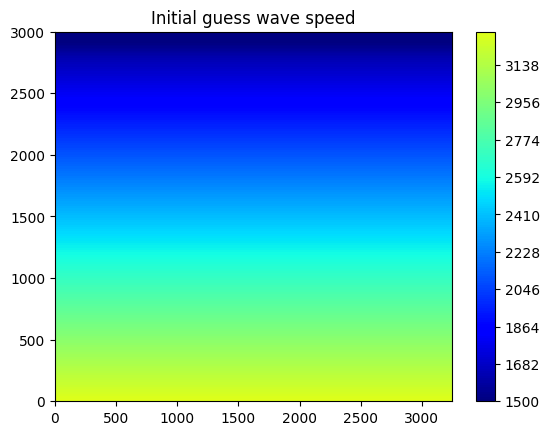

In [84]:
# c0 = c_true.mean(axis=(0, 2), keepdims=True) * np.ones_like(np.ones_like(c_true))
# c0 = smooth_interp(pts).reshape(forward_solver.c.shape)
# c0 = np.ones_like(c_exact) * c_water
c0 = c_water - (ys - ylim) * 0.6
c0[water_mask] = c_water
c0_w = c0 * optimizers_dict[freqs[0]][0].M_half

plt.title(f'Initial guess wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c0.ravel(), levels=1000, cmap='jet', vmax=c_exact.max())
plt.colorbar()

In [27]:
def fix_wavespeed(c_in):
    c_shape = optimizers[0].forward_solver.c.shape
    c_out = np.copy(c_in.reshape(c_shape))
    c_out[water_mask] = c_water

    return c_out.reshape(c_in.shape)


def fix_wavespeed_w(c_w_in):
    c_shape = optimizers[0].forward_solver.c.shape
    c_in = optimizers[0].M_half_inv * c_w_in.reshape(c_shape)
    c_out = fix_wavespeed(c_in)

    c_w_out = c_out * optimizers[0].M_half

    return c_w_out.reshape(c_w_in.shape)

In [77]:
def recover(c_w_in, optimizers):
    c_w_out = (np.ones_like(optimizers[0].forward_solver.c) * c_water) * optimizers[0].M_half
    c_w_out[~water_mask] = c_w_in
    return c_w_out


def project(c_w_in, optimizers):
    
    c_shape = optimizers[0].forward_solver.c.shape
    return c_w_in.reshape(c_shape)[~water_mask]

In [157]:
c0_pr = project(c0 * optimizers_dict[freqs[0]][0].M_half, optimizers)
c_exact_pr = project(c_exact * optimizers_dict[freqs[0]][0].M_half, optimizers)

In [86]:
mu = 0.0


def cost_function_w(c_w_in, optimizers):
    c_w_in = fix_wavespeed_w(c_w_in)
    penalty = (c_w_in**2).sum()
    return sum(optimizer.cost_function_w(c_w_in) for optimizer in optimizers) + 0.5 * mu * penalty


def jac_function_w(c_w_in, optimizers):
    c_w_in = fix_wavespeed_w(c_w_in)
    out = sum(optimizer.jac_function_w(c_w_in) for optimizer in optimizers) + mu * c_w_in.ravel()

    c_shape = optimizers[0].forward_solver.c.shape
    out = out.reshape(c_shape)
    out[water_mask] = 0.0
    return out.ravel() 

In [87]:
mu = 0.0


def cost_function_pr(c_w_in, optimizers):
    c_w_in = recover(c_w_in, optimizers)
    penalty = (c_w_in**2).sum()
    return sum(optimizer.cost_function_w(c_w_in) for optimizer in optimizers) + 0.5 * mu * penalty


def jac_function_pr(c_w_in, optimizers):
    c_w_in = recover(c_w_in, optimizers)
    out = sum(optimizer.jac_function_w(c_w_in) for optimizer in optimizers) + mu * c_w_in.ravel()

    c_shape = optimizers[0].forward_solver.c.shape
    out = out.reshape(c_shape)
    # out[water_mask] = 0.0
    return out[~water_mask].ravel() 

In [151]:
dc = np.random.random(c0.shape)


In [152]:
dc_w = (dc * optimizers[0].M_half)
    
dc_pr = (dc * optimizers[0].M_half)[~water_mask]

In [153]:
eps = 1e-5
optimizers = optimizers_dict[1.0]
dcost = cost_function_pr(c0_pr + 0.5 * dc_pr, optimizers=optimizers) - cost_function_pr(c0_pr - 0.5 * dc_pr, optimizers=optimizers)
dcost_est = (jac_function_pr(c0_pr, optimizers=optimizers) * dc_pr.ravel()).sum()

print(dcost)
print(dcost_est)
print(abs((dcost - dcost_est) / dcost))

-911.5836716501799
-911.5834209354409
2.750320642690097e-07


In [154]:
eps = 1e-5
optimizers = optimizers_dict[1.0]
dcost = cost_function_w(c0_w + 0.5 * dc_w, optimizers=optimizers) - cost_function_w(c0_w - 0.5 * dc_w, optimizers=optimizers)
dcost_est = (jac_function_w(c0_w, optimizers=optimizers) * dc_w.ravel()).sum()

print(dcost)
print(dcost_est)
print(abs((dcost - dcost_est) / dcost))

-911.583671650209
-911.5834209354401
2.7503209706866513e-07


In [101]:
c_est = np.copy(c0)

c_hist = [np.copy(c_est)]

for f0 in freqs[:3]:

    print(f'Running freq {f0}')

    # setup cost functions
    optimizers = optimizers_dict[f0]
    cost_function_hf = lambda c: cost_function_pr(c, optimizers=optimizers)
    jac_function_hf = lambda c: jac_function_pr(c, optimizers=optimizers)

    # report initial error
    c_est_pr = project(c_est * optimizers[0].M_half, optimizers)
    c_error = c_est - c_exact
    
    print('Initial wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Initial seismometer RMSE:', np.sqrt(2 * cost_function_hf(c_est_pr) / (len(optimizers) * xlim)), 'm/s')

    # optimizer
    options = {
        'maxiter': 300,
        'ftol': 1e-8,
        'gtol': 1e-6,
        'maxcor': 5
    }
    
    result = scipy.optimize.minimize(
        cost_function_hf, c_est_pr.ravel(), jac=jac_function_hf, method='L-BFGS-B', options=options
    )
    
    c_est = recover(result.x, optimizers).reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
    c_est_pr = project(c_est * optimizers[0].M_half, optimizers)
    c_error = c_est - c_exact

    print('Final wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Final seismo1meter RMSE:', np.sqrt(2 * cost_function_hf(c_est_pr) / (len(optimizers) * xlim)), 'm/s')
    
    c_hist.append(np.copy(c_est))
    
    print()


Running freq 1.0
Initial wave speed (c) RMSE: 525.5142466650872 m/s
Initial seismometer RMSE: 5.176778765121512 m/s
Final wave speed (c) RMSE: 173.03742684393018 m/s
Final seismo1meter RMSE: 0.021792638046991705 m/s

Running freq 1.75
Initial wave speed (c) RMSE: 173.03742684393018 m/s
Initial seismometer RMSE: 0.40455244763001924 m/s


KeyboardInterrupt: 

In [104]:
for f0 in freqs[1:]:

    print(f'Running freq {f0}')

    # setup cost functions
    optimizers = optimizers_dict[f0]
    cost_function_w_hf = lambda c: cost_function_w(c, optimizers=optimizers)
    jac_function_w_hf = lambda c: jac_function_w(c, optimizers=optimizers)

    # report initial error
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact
    
    print('Initial wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Initial seismometer RMSE:', np.sqrt(2 * cost_function_w_hf(c_est_w) / (len(optimizers) * xlim)), 'm/s')

    # optimizer
    options = {
        'maxiter': 100,
        'ftol': 1e-8,
        'gtol': 1e-6,
        'maxcor': 5
    }
    
    result = scipy.optimize.minimize(
        cost_function_w_hf, c_est_w.ravel(), jac=jac_function_w_hf, method='L-BFGS-B', options=options
    )
    
    c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact

    print('Final wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Final seismometer RMSE:', np.sqrt(2 * cost_function_w_hf(c_est_w) / (len(optimizers) * xlim)), 'm/s')
    
    c_hist.append(np.copy(c_est))
    
    print()

Running freq 1.75
Initial wave speed (c) RMSE: 173.03742684393018 m/s
Initial seismometer RMSE: 0.4045524476300184 m/s
Final wave speed (c) RMSE: 149.19645744168204 m/s
Final seismometer RMSE: 0.08731775532641184 m/s

Running freq 2.5
Initial wave speed (c) RMSE: 149.19645744168204 m/s
Initial seismometer RMSE: 0.3913203411797032 m/s
Final wave speed (c) RMSE: 132.57264426675377 m/s
Final seismometer RMSE: 0.11696764745541759 m/s

Running freq 5.0
Initial wave speed (c) RMSE: 132.57264426675377 m/s
Initial seismometer RMSE: 0.5021142171963733 m/s
Final wave speed (c) RMSE: 120.53643439894778 m/s
Final seismometer RMSE: 0.17012768785315846 m/s

Running freq 7.5
Initial wave speed (c) RMSE: 120.53643439894778 m/s
Initial seismometer RMSE: 0.1901311420137306 m/s
Final wave speed (c) RMSE: 113.47161754450023 m/s
Final seismometer RMSE: 0.1189278139051565 m/s

Running freq 10.0
Initial wave speed (c) RMSE: 113.47161754450023 m/s
Initial seismometer RMSE: 0.10851381903099723 m/s
Final wave s

# Plots with depth wave speed profile intial condition

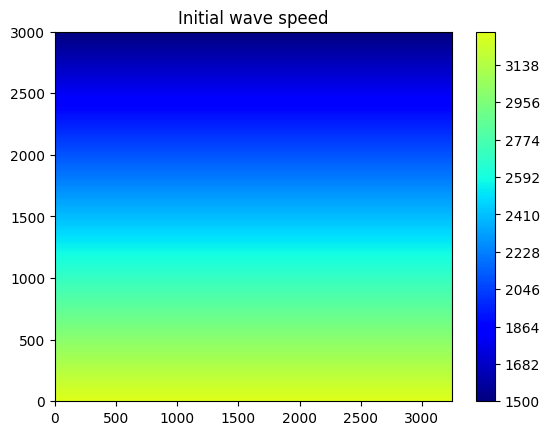

In [40]:
plt.title(f'Initial wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_hist[0].ravel(), levels=1000, cmap='jet', vmax=c_exact.max())
plt.colorbar()

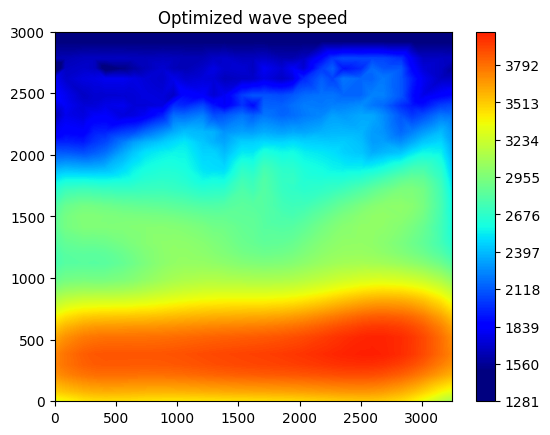

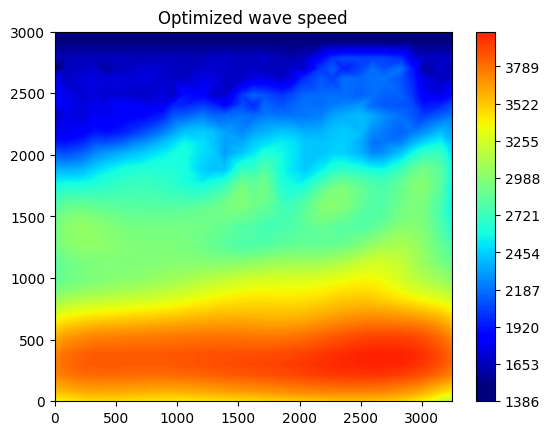

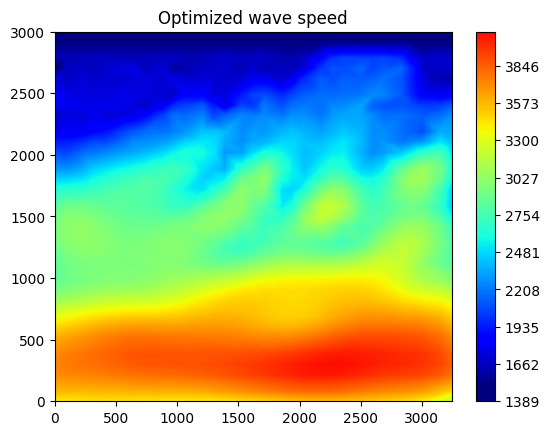

In [107]:
for c_ in c_hist[1:4]:
    plt.figure()
    plt.title(f'Optimized wave speed')
    plt.tricontourf(xs.ravel(), ys.ravel(), c_.ravel(), levels=1000, cmap='jet',  vmin=1500, vmax=c_exact.max())
    plt.colorbar()

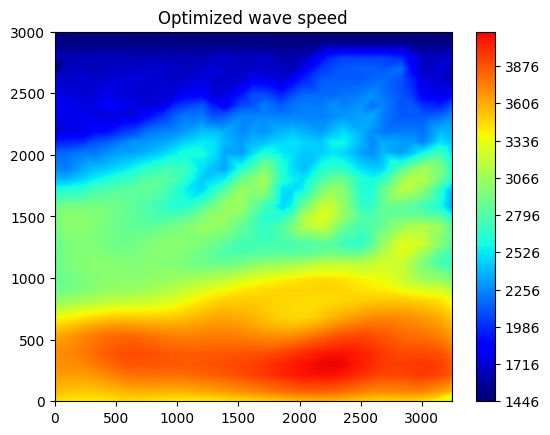

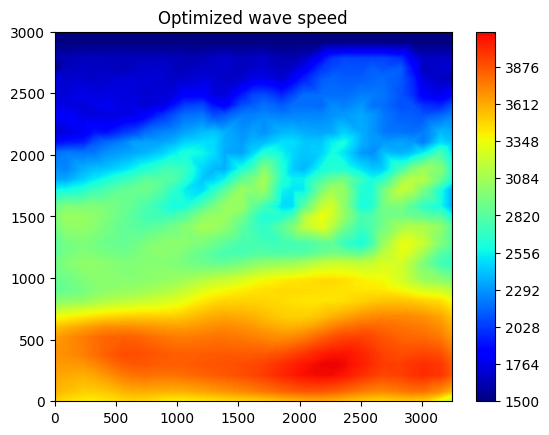

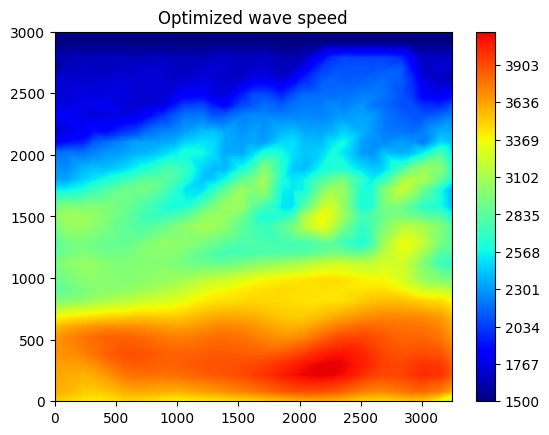

In [109]:
for c_ in c_hist[4:7]:
    plt.figure()
    plt.title(f'Optimized wave speed')
    plt.tricontourf(xs.ravel(), ys.ravel(), c_.ravel(), levels=1000, cmap='jet', vmin=1500, vmax=c_exact.max())
    plt.colorbar()

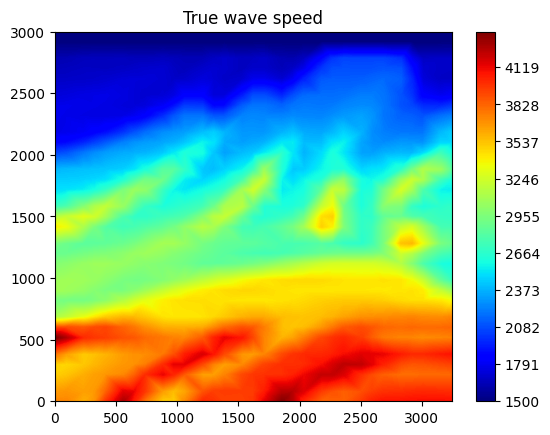

In [43]:
plt.title(f'True wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_exact.ravel(), levels=1000, cmap='jet', vmax=c_exact.max())
plt.colorbar()

## Quasi-newton touch up

In [146]:
def G_matvec(dc_pr, optimizers):
    dc = np.zeros_like(optimizers[0].forward_solver.c)
    dc[~water_mask] = dc_pr

    return np.concatenate([optimizer.G_matvec(dc) for optimizer in optimizers])

In [135]:
def G_rmatvec(y, optimizers):
    y = y.reshape((len(optimizers), -1))

    out = sum(optimizers[i].G_rmatvec(y[i]) for i in range(len(optimizers)))

    return out.reshape(optimizers[0].forward_solver.c.shape)[~water_mask]

In [149]:
# check combined adjoint is correct

v1 = np.random.random(int((~water_mask).sum()))
v2 = np.random.random(len(optimizers) * optimizers[0].target_data[:, :2].size)

out1 = (v2 * G_matvec(v1, optimizers_dict[1.0])).sum()
out2 = (v1 * G_rmatvec(v2, optimizers_dict[1.0])).sum()

print('Rel error:', abs((out1 - out2) / out1))

Rel error: 7.13785416033422e-13


In [162]:
grad = jac_function_pr(c_exact_pr, optimizers=optimizers)
optimizers = optimizers_dict[1.0]
hess_dc = G_rmatvec(G_matvec(dc_pr, optimizers=optimizers), optimizers=optimizers)

In [161]:
eps = 1e-5
optimizers = optimizers_dict[1.0]
dcost = cost_function_pr(c_exact_pr + eps * dc_pr, optimizers=optimizers)
dcost_est = 0.5 * eps**2 * (dc_pr * hess_dc).sum()

print(dcost)
print(dcost_est)
print(abs((dcost - dcost_est) / dcost))

1.2796822074387353e-10
1.279682190607031e-10
1.3153034533044398e-08


In [191]:
def optimization_step(c_in, optimizers, maxiter=10, verbose=False):

    b = -np.concatenate([(optimizer.error(c_in, fill_gradient=True) * optimizer.W_half).ravel() for optimizer in optimizers])

    G = LinearOperator(
        shape=(b.size, int((~water_mask).sum())),
        matvec=partial(G_matvec, optimizers=optimizers),
        rmatvec=partial(G_rmatvec, optimizers=optimizers),
        dtype=np.float64
    )
    
    result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=maxiter)
    dc_pr = result[0]

    dc = np.zeros_like(optimizers[0].forward_solver.c)
    dc[~water_mask] = dc_pr

    c_out = c_in + dc * optimizers[0].M_half_inv

    if verbose:
        print('Relative linear error:', result[3] / np.linalg.norm(b))

    return c_out, result

In [202]:
optimizers = optimizers_dict[10.0]
cost_function_w_hf = lambda c: cost_function_w(c, optimizers=optimizers)

In [203]:
c_est_w = c_est * optimizers[0].M_half
c_error = c_est - c_exact

print('Initial wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
print('Initial seismometer RMSE:', np.sqrt(2 * cost_function_w_hf(c_est_w) / (len(optimizers) * xlim)), 'm/s')

Initial wave speed (c) RMSE: 108.22090626590209 m/s
Initial seismometer RMSE: 0.08374545219098589 m/s


In [204]:
c_out, result = optimization_step(c_est, optimizers, maxiter=10)
c_error = c_out - c_exact

c_out_w = c_out * optimizers[0].M_half
c_error = c_out - c_exact

print('Final wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
print('Final seismometer RMSE:', np.sqrt(2 * cost_function_w_hf(c_out_w) / (len(optimizers) * xlim)), 'm/s')

print('Linear error:', result[3] / (len(optimizers) * xlim))

Final wave speed (c) RMSE: 108.14858209297843 m/s
Final seismometer RMSE: 0.08091811786573688 m/s
Linear error: 0.0006354067051633465


In [206]:
c_est = c_hist[-1]

for f0 in freqs:

    print(f'Running freq {f0}')

    # setup cost functions
    optimizers = optimizers_dict[f0]
    cost_function_w_hf = lambda c: cost_function_w(c, optimizers=optimizers)
    
    # report initial error
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact
    
    print('Initial wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Initial seismometer RMSE:', np.sqrt(2 * cost_function_w_hf(c_est_w) / (len(optimizers) * xlim)), 'm/s')

    c_est, result = optimization_step(c_est, optimizers, maxiter=200)
    
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact

    print('Final wave speed (c) RMSE:', np.sqrt((c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Final seismometer RMSE:', np.sqrt(2 * cost_function_w_hf(c_est_w) / (len(optimizers) * xlim)), 'm/s')
    print('Linear error:', result[3] / (len(optimizers) * xlim))
    
    c_hist.append(np.copy(c_est))
    
    print()

Running freq 1.0
Initial wave speed (c) RMSE: 108.22090626590209 m/s
Initial seismometer RMSE: 0.026664715115558093 m/s
Final wave speed (c) RMSE: 103.29614824318132 m/s
Final seismometer RMSE: 0.003484049714121642 m/s
Linear error: 2.5472774272934043e-05

Running freq 1.75
Initial wave speed (c) RMSE: 103.29614824318132 m/s
Initial seismometer RMSE: 0.08785423644282009 m/s
Final wave speed (c) RMSE: 97.40090411663512 m/s
Final seismometer RMSE: 0.009703092816920693 m/s
Linear error: 6.747375977333247e-05

Running freq 2.5
Initial wave speed (c) RMSE: 97.40090411663512 m/s
Initial seismometer RMSE: 0.04217482485048658 m/s
Final wave speed (c) RMSE: 92.71504278839289 m/s
Final seismometer RMSE: 0.016583029619621506 m/s
Linear error: 0.00012396569270850717

Running freq 5.0
Initial wave speed (c) RMSE: 92.71504278839289 m/s
Initial seismometer RMSE: 0.08556106519856768 m/s
Final wave speed (c) RMSE: 83.55363528419382 m/s
Final seismometer RMSE: 0.038906735796114346 m/s
Linear error: 0.00

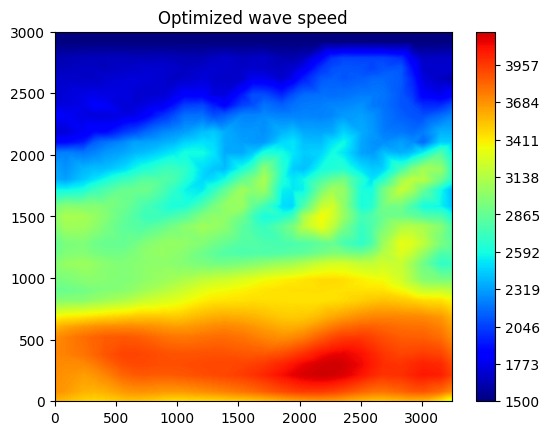

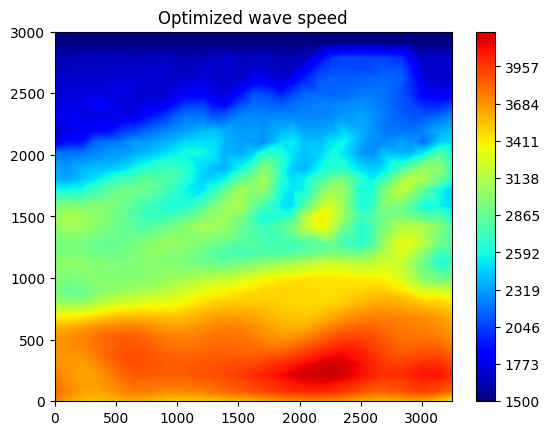

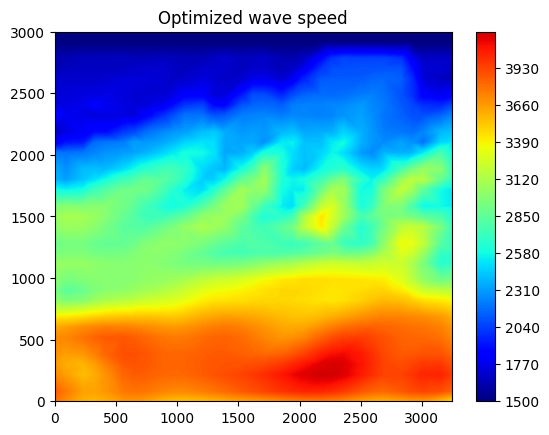

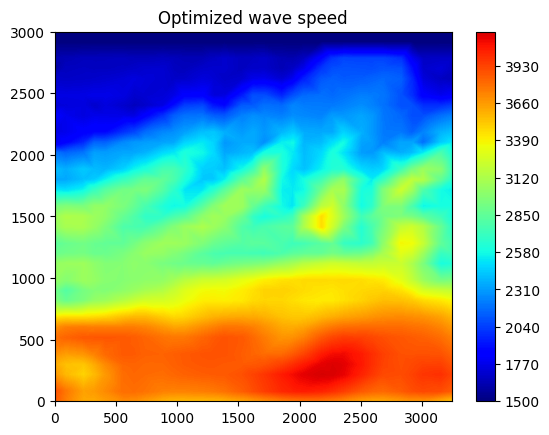

In [208]:
for c_ in c_hist[7:11]:
    plt.figure()
    plt.title(f'Optimized wave speed')
    plt.tricontourf(xs.ravel(), ys.ravel(), c_.ravel(), levels=1000, cmap='jet',  vmin=1500, vmax=c_exact.max())
    plt.colorbar()

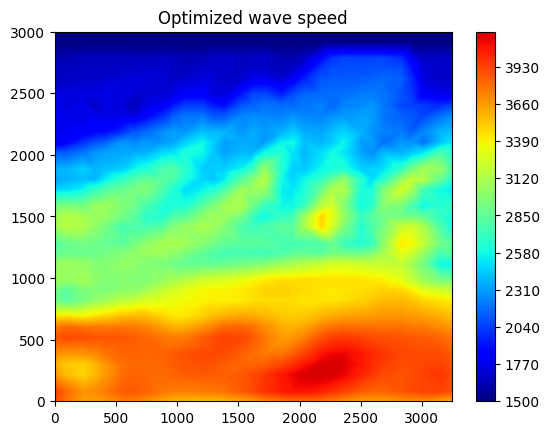

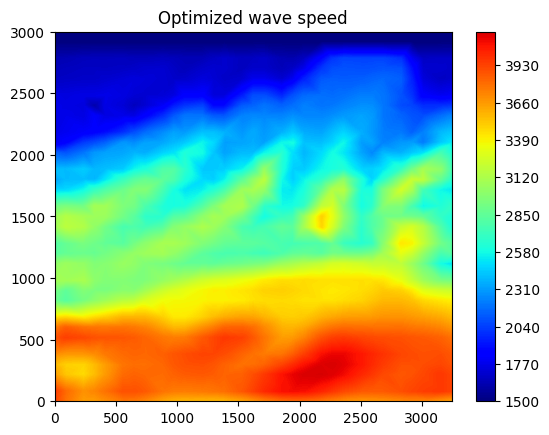

In [209]:
for c_ in c_hist[11:]:
    plt.figure()
    plt.title(f'Optimized wave speed')
    plt.tricontourf(xs.ravel(), ys.ravel(), c_.ravel(), levels=1000, cmap='jet',  vmin=1500, vmax=c_exact.max())
    plt.colorbar()

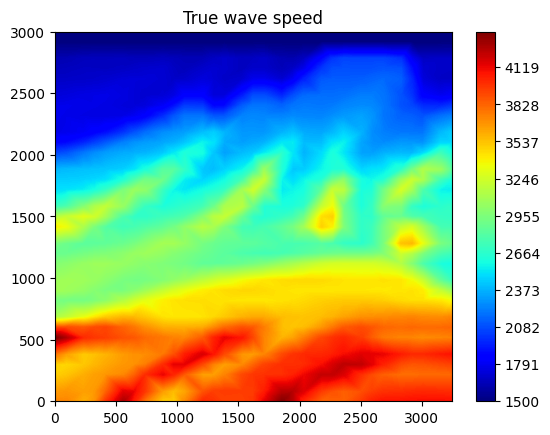

In [210]:
plt.title(f'True wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_exact.ravel(), levels=1000, cmap='jet', vmax=c_exact.max())
plt.colorbar()